In [1]:
import tangram as tg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
import itertools
from tqdm import tqdm
import random
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import issparse
import scipy
from scanpy import AnnData
import time

import warnings
warnings.filterwarnings("ignore")

/slurm/home/yrd/fanlab/qianjingyang/.conda/envs/sccube/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    
def integer_allocation(prop, counts):
    expected_cells = prop * counts[:, None]
    int_cells = np.floor(expected_cells).astype(int)
    frac_cells = expected_cells - int_cells
    remaining_cells = counts - int_cells.sum(axis=1)
    for i in range(len(counts)):
        frac_order = np.argsort(-frac_cells[i])
        for j in range(remaining_cells[i]):
            int_cells[i, frac_order[j]] += 1
    return int_cells


def jitter_coord(coord):
    # cell number
    num = coord.shape[0]
    # min distance
    coord_unique = np.unique(coord, axis=0)
    nbrs = NearestNeighbors(n_neighbors=2).fit(coord_unique)
    distances, indices = nbrs.kneighbors(coord_unique)
    min_distance = min(distances[:, -1][distances[:, -1] > 0])

    x_list = list(coord[:, 0])
    y_list = list(coord[:, 1])

    set_seed(0)
    length = np.random.uniform(0, min_distance, num)
    radius = np.pi * np.random.uniform(0, 2, num)

    x_list_new = x_list + length * np.cos(radius)
    y_list_new = y_list + length * np.sin(radius)
    coord_new = np.array([[x_list_new[i], y_list_new[i]] for i in range(num)])

    return coord_new


def adjust_abundance(
    adata_st: AnnData,
    adata_sc: AnnData,
    celltype_key: str = 'celltype',
):
    celltype_unique = sorted(set(adata_sc.obs[celltype_key]))
    
    cell_counts = np.array(adata_st.obs['estimated_cell_number'])
    prop = np.array(adata_st.obs[celltype_unique].copy())
    map_target = integer_allocation(prop, cell_counts)
    
    target_num_list = map_target.sum(axis=0)
    sc_num_list = np.array(adata_sc.obs[celltype_key].value_counts()[celltype_unique])
    diff_num_list = sc_num_list - target_num_list
    
    adata_list = []
    for i in range(len(celltype_unique)):
        adata_tmp = adata_sc[adata_sc.obs[celltype_key] == celltype_unique[i]].copy()
        adata_list.append(adata_tmp)
        
    print(f"Adjust abundance of each cell types")
    for i in tqdm(range(len(celltype_unique))):
        adjust_num = diff_num_list[i]
        adata_tmp = adata_list[i].copy()
        if adjust_num >= 0:
            set_seed(0)
            selected_indices = np.random.choice(adata_tmp.shape[0], size=target_num_list[i], replace=False)
            adata_tmp = adata_tmp[selected_indices]
        elif adjust_num < 0:
            fold = np.abs(diff_num_list[i]) / sc_num_list[i]
            if fold > 1:
                fold_int = int(fold)
                selected_indices = list(range(adata_tmp.shape[0])) * fold_int
                set_seed(0)
                selected_indices2 = list(
                    np.random.choice(adata_tmp.shape[0], size=(np.abs(diff_num_list[i]) - fold_int * adata_tmp.shape[0]), replace=False)
                )
                selected_indices.extend(selected_indices2)
                selected_indices = np.array(selected_indices)
            else:
                set_seed(0)
                selected_indices = np.random.choice(adata_tmp.shape[0], size=np.abs(diff_num_list[i]), replace=False)
            
            adata_tmp_replicate = adata_tmp[selected_indices].copy()
            adata_tmp = sc.concat([adata_tmp, adata_tmp_replicate]).copy()
            
        adata_list[i] = adata_tmp.copy()
        
    adata_sc_new = sc.concat(adata_list).copy()
    adata_sc_new.obs_names_make_unique()
    print(f"Done")
    
    return adata_st, adata_sc_new


def process_result(
    adata_st: AnnData,
    adata_sc: AnnData,
    transport_matrix: np.array,
    celltype_key: str = 'celltype',
):
    
    print(f"Assign cells")
    spot_to_cells = []
    cell_counts = adata_st.obs['estimated_cell_number']
    for i in tqdm(range(transport_matrix.shape[1])):
        k = int(cell_counts[i])
        top_k_cells = np.argsort(-transport_matrix[:, i])[:k]
        spot_to_cells.append(list(top_k_cells))
        
    print(f"Create new data")
    if issparse(adata_sc.X):
        adata_sc.X = adata_sc.X.toarray()
        
    # original
    original_spot = list(adata_st.obs_names)
    original_cell = list(adata_sc.obs_names)
    original_celltype = list(adata_sc.obs[celltype_key])
    original_x = list(adata_st.obsm['spatial'][:, 0])
    original_y = list(adata_st.obsm['spatial'][:, 1])
    original_expr = adata_sc.X
    
    # new
    cell_list = []
    celltype_list = []
    spot_list = []
    x_list = []
    y_list = []
    expr_list = []
    
    for i, indices in enumerate(spot_to_cells):
        cell_list.extend(original_cell[idx] for idx in indices)
        celltype_list.extend(original_celltype[idx] for idx in indices)

        spot_list.extend([original_spot[i]] * len(indices))
        x_list.extend([original_x[i]] * len(indices))
        y_list.extend([original_y[i]] * len(indices))

        expr_list.extend(original_expr[indices])
        
    new_id_list = ['CID' + str(i + 1) for i in range(len(cell_list))]
    
    new_meta = pd.DataFrame({
        'NewCID': new_id_list,
        'OriginalCID': cell_list,
        'CellType': celltype_list,
        'SpotID': spot_list,
        'X': x_list,
        'Y': y_list,
    })
    
    new_meta.index = new_id_list
    new_expr = np.array(expr_list)
    new_expr = scipy.sparse.csr_matrix(new_expr)
    coord = np.array(new_meta[['X', 'Y']])
    coord_jitter = jitter_coord(coord)
    
    new_meta['X_jitter'] = coord_jitter[:, 0]
    new_meta['Y_jitter'] = coord_jitter[:, 1]

    # new AnnData
    adata_new = sc.AnnData(new_expr)
    adata_new.obs = new_meta
    adata_new.obs_names = new_id_list
    adata_new.var_names = adata_sc.var_names
    adata_new.obsm['spatial'] = coord_jitter
    
    print("Done")
    return adata_new


In [3]:
ad_sp = sc.read('../processed/st_adata.h5ad')
ad_sc = sc.read('../processed/sc_adata.h5ad')

In [4]:
# load deconvolution results
prop = pd.read_csv('../results/C2L_res.csv', index_col=0)
ct_sort = sorted(set(ad_sc.obs['Cell_type']))
prop = prop[ct_sort]
prop = prop.loc[ad_sp.obs_names]


# prop
obs_raw = ad_sp.obs.copy()
obs_new = pd.concat([obs_raw, prop], axis=1)
    
ad_sp.obs = obs_new

In [5]:
# scPositioner results
scpositioner_res = sc.read('../results/scPositioner_result.h5ad')
ad_sp.obs["estimated_cell_number"] = np.array(scpositioner_res.obs['SpotID'].value_counts()[ad_sp.obs_names])

# run
start_time = time.time()
ad_sp, ad_sc = adjust_abundance(
    adata_st = ad_sp.copy(),
    adata_sc = ad_sc.copy(),
    celltype_key='Cell_type',
)
end_time = time.time()
print(f"Adjust abundance step time: {end_time - start_time:.2f} seconds")

Adjust abundance of each cell types


100%|██████████| 6/6 [00:00<00:00, 10.32it/s]


Done
Adjust abundance step time: 1.01 seconds


In [6]:
start_time = time.time()
celltype_key = 'Cell_type'
adata_sc = ad_sc.copy()
sc.pp.normalize_total(adata_sc, target_sum=1e6)
sc.pp.log1p(adata_sc)

sc.tl.rank_genes_groups(adata_sc, celltype_key, method='wilcoxon')
marker_df = pd.DataFrame(adata_sc.uns['rank_genes_groups']['names']).head(100)
marker_list = list(itertools.chain(*marker_df.to_numpy().T.tolist()))
marker_list = list(set(marker_list))

end_time = time.time()
print(f"Calculate marker genes step time: {end_time - start_time:.2f} seconds")

Calculate marker genes step time: 14.84 seconds


In [7]:
start_time = time.time()
tg.pp_adatas(ad_sc, ad_sp, genes=marker_list)
end_time = time.time()
print(f"Preprocess step time: {end_time - start_time:.2f} seconds")

INFO:root:499 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:14524 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


Preprocess step time: 2.51 seconds


In [8]:
start_time = time.time()
ad_map = tg.map_cells_to_space(
    ad_sc,
    ad_sp,
    target_count=ad_sp.obs.estimated_cell_number.sum(),
    density_prior=np.array(ad_sp.obs.estimated_cell_number) / ad_sp.obs.estimated_cell_number.sum(),
    num_epochs=500,
    device="cuda:0",
)
end_time = time.time()
print(f"Mapping step time: {end_time - start_time:.2f} seconds")

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 499 genes and customized density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.736, KL reg: 0.009
Score: 0.921, KL reg: 0.001
Score: 0.929, KL reg: 0.000
Score: 0.931, KL reg: 0.000
Score: 0.932, KL reg: 0.000


INFO:root:Saving results..


Mapping step time: 19.71 seconds


In [9]:
# run
transport_matrix = ad_map.X.copy()

start_time = time.time()
adata_new = process_result(
    adata_st=ad_sp.copy(),
    adata_sc=ad_sc.copy(),
    transport_matrix=transport_matrix,
    celltype_key='Cell_type',
)
end_time = time.time()
print(f"Process result step time: {end_time - start_time:.2f} seconds")

Assign cells


100%|██████████| 3124/3124 [00:03<00:00, 826.53it/s]


Create new data
Done
Process result step time: 6.52 seconds


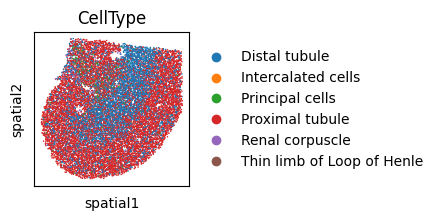

In [10]:
plt.rcParams["figure.figsize"] = (2, 2)
sc.pl.embedding(adata_new, basis='spatial', color='CellType', s=5)

In [11]:
adata_new.var_names = [item.upper() for item in adata_new.var_names]
adata_new.write('../results/Tangram_marker_result.h5ad')